#  Analisis de anuncions de coches.


In [20]:
import pandas as pd
import seaborn as sns

In [21]:
df = pd.read_csv("../data/coches-de-segunda-mano-sample.csv")
df

,url,company,make,model,version,price,price_financed,fuel,year,kms,...,doors,shift,color,photos,is_professional,dealer,province,country,publish_date,insert_date
0,e158ae0ca53119ca199c28c36b5c2fcd,9881bcdd5a0ad4733037b3fb25e69c3a,SEAT,Toledo,SEAT Toledo 4p.,950,NaN,Diésel,2000.0,227000,...,4,Manual,Verde,5,False,0f4bb8455d27349b8273109b66a847f3,Navarra,Spain,2020-12-18 10:47:13,2021-01-15 00:00:00
1,ff267ebb7e700246f47f84f3db660b4b,9881bcdd5a0ad4733037b3fb25e69c3a,CITROEN,C1,CITROEN C1 PureTech 60KW 82CV Feel 5p.,6200,NaN,Gasolina,2017.0,50071,...,5,Manual,Blanco,6,True,Autos Raymara,Tenerife,Spain,2021-01-02 11:25:40,2021-01-15 00:00:00
2,de4b02db28ea7786c622b969be10c7c7,9881bcdd5a0ad4733037b3fb25e69c3a,FORD,Transit Connect,FORD Transit Connect Van 1.5 TDCi 100cv Ambien...,7851,7024.0,Diésel,2016.0,103000,...,4,Manual,Blanco,10,True,Auto 96,Barcelona,Spain,2020-12-16 10:51:45,2021-01-15 00:00:00
3,0449972a4d07594acf92e9a7dd28b39c,9881bcdd5a0ad4733037b3fb25e69c3a,VOLKSWAGEN,Caravelle,VOLKSWAGEN Caravelle Largo 2.0 TDI 140 Comfort...,19426,NaN,Diésel,2014.0,120000,...,4,Manual,Blanco,9,True,Inniauto,Navarra,Spain,2020-11-25 11:09:14,2021-01-15 00:00:00
4,12c4fa49bd4fdf23f19ecf396d3f02ef,9881bcdd5a0ad4733037b3fb25e69c3a,FORD,Transit,FORD Transit 350 96kW L4 Ambiente Propulsion T...,22850,22800.0,Diésel,2017.0,107000,...,2,Manual,Blanco,4,True,"Autofleet España,s.l",Sevilla,Spain,2021-01-12 20:00:34,2021-01-15 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,730210734bfbe1d3df878d5df71246f2,9881bcdd5a0ad4733037b3fb25e69c3a,HYUNDAI,i30,HYUNDAI i30 1.4 TGDI Tecno Fastback DCT 5p.,18490,16490.0,Gasolina,2018.0,47000,...,5,Automático,Gris / Plata,26,True,Flexicar Málaga,Málaga,Spain,2020-11-24 19:59:52,2021-01-15 00:00:00
49996,732b04fb47dd9559dbdcd099c5af484e,9881bcdd5a0ad4733037b3fb25e69c3a,RENAULT,Laguna,RENAULT Laguna Coupe Limited 2.0 Energy dCi 15...,14500,13551.0,Diésel,2015.0,68750,...,2,Manual,KNG Gris Casiopea (metalizado),30,True,Ocasion Plus,Málaga,Spain,2021-01-13 17:02:41,2021-01-15 00:00:00
49997,c10afb53957fb8012707239bdfa66018,9881bcdd5a0ad4733037b3fb25e69c3a,PEUGEOT,108,PEUGEOT 108 TOP Allure VTi 52kW 72CV 5p.,11000,9000.0,Gasolina,2019.0,21422,...,5,Manual,Gris / Plata,17,True,Psa Retail Huelva,Huelva,Spain,2021-01-08 16:47:24,2021-01-15 00:00:00
49998,f74363a6688ba11b71b4d980a959b8d3,9881bcdd5a0ad4733037b3fb25e69c3a,AUDI,RS4,AUDI RS4 Avant 4.2 FSI 450cv quattro 5p.,47900,NaN,Gasolina,2013.0,47900,...,5,Automático,Gris / Plata (Antracita),20,True,Codigocar Lugo,Lugo,Spain,2021-01-13 16:22:53,2021-01-15 00:00:00


In [22]:
df["company"].value_counts()

company
9881bcdd5a0ad4733037b3fb25e69c3a    50000
Name: count, dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              50000 non-null  object 
 1   company          50000 non-null  object 
 2   make             49998 non-null  object 
 3   model            49995 non-null  object 
 4   version          50000 non-null  object 
 5   price            50000 non-null  int64  
 6   price_financed   23563 non-null  float64
 7   fuel             49954 non-null  object 
 8   year             49998 non-null  float64
 9   kms              50000 non-null  int64  
 10  power            41472 non-null  float64
 11  doors            50000 non-null  int64  
 12  shift            49889 non-null  object 
 13  color            49406 non-null  object 
 14  photos           50000 non-null  int64  
 15  is_professional  50000 non-null  bool   
 16  dealer           50000 non-null  object 
 17  province    

<Axes: >

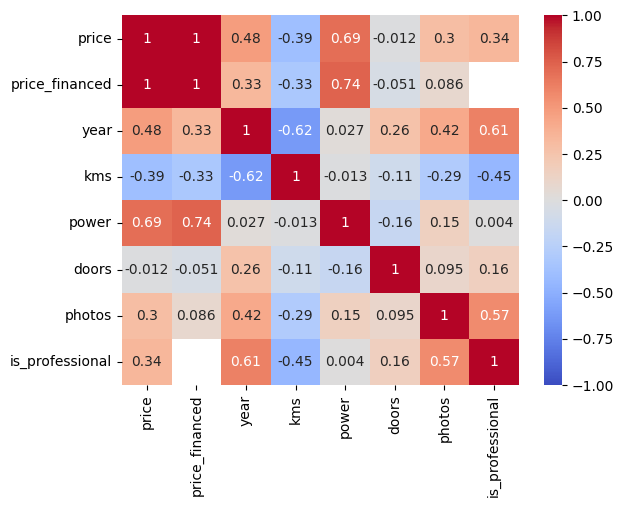

In [24]:
sns.heatmap(df.corr(numeric_only= True), annot= True, cmap = "coolwarm", vmin = -1)

### Columnas a eliminar:
- Precio financiado.
- Company
- url
- fechaas anuncio.
- Pais y región.


In [25]:
df = df.drop(columns= ["url", "company", "publish_date", "insert_date", "province", "country", "dealer", "price_financed"])

In [26]:
df.head()

,make,model,version,price,fuel,year,kms,power,doors,shift,color,photos,is_professional
0,SEAT,Toledo,SEAT Toledo 4p.,950,Diésel,2000.0,227000,NaN,4,Manual,Verde,5,False
1,CITROEN,C1,CITROEN C1 PureTech 60KW 82CV Feel 5p.,6200,Gasolina,2017.0,50071,82.0,5,Manual,Blanco,6,True
2,FORD,Transit Connect,FORD Transit Connect Van 1.5 TDCi 100cv Ambien...,7851,Diésel,2016.0,103000,100.0,4,Manual,Blanco,10,True
3,VOLKSWAGEN,Caravelle,VOLKSWAGEN Caravelle Largo 2.0 TDI 140 Comfort...,19426,Diésel,2014.0,120000,140.0,4,Manual,Blanco,9,True
4,FORD,Transit,FORD Transit 350 96kW L4 Ambiente Propulsion T...,22850,Diésel,2017.0,107000,130.0,2,Manual,Blanco,4,True


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   make             49998 non-null  object 
 1   model            49995 non-null  object 
 2   version          50000 non-null  object 
 3   price            50000 non-null  int64  
 4   fuel             49954 non-null  object 
 5   year             49998 non-null  float64
 6   kms              50000 non-null  int64  
 7   power            41472 non-null  float64
 8   doors            50000 non-null  int64  
 9   shift            49889 non-null  object 
 10  color            49406 non-null  object 
 11  photos           50000 non-null  int64  
 12  is_professional  50000 non-null  bool   
dtypes: bool(1), float64(2), int64(4), object(6)
memory usage: 4.6+ MB


In [15]:
df["model"].nunique()

940

In [29]:
df.dropna(inplace= True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41251 entries, 1 to 49999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   make             41251 non-null  object 
 1   model            41251 non-null  object 
 2   version          41251 non-null  object 
 3   price            41251 non-null  int64  
 4   fuel             41251 non-null  object 
 5   year             41251 non-null  float64
 6   kms              41251 non-null  int64  
 7   power            41251 non-null  float64
 8   doors            41251 non-null  int64  
 9   shift            41251 non-null  object 
 10  color            41251 non-null  object 
 11  photos           41251 non-null  int64  
 12  is_professional  41251 non-null  bool   
dtypes: bool(1), float64(2), int64(4), object(6)
memory usage: 4.1+ MB


In [31]:
df["shift"].value_counts()

shift
Manual        27223
Automático    14028
Name: count, dtype: int64

In [32]:
from sklearn.preprocessing import LabelEncoder

label_en = LabelEncoder()
df["shift_int"] = label_en.fit_transform(df["shift"])
df

,make,model,version,price,fuel,year,kms,power,doors,shift,color,photos,is_professional,shift_int
1,CITROEN,C1,CITROEN C1 PureTech 60KW 82CV Feel 5p.,6200,Gasolina,2017.0,50071,82.0,5,Manual,Blanco,6,True,1
2,FORD,Transit Connect,FORD Transit Connect Van 1.5 TDCi 100cv Ambien...,7851,Diésel,2016.0,103000,100.0,4,Manual,Blanco,10,True,1
3,VOLKSWAGEN,Caravelle,VOLKSWAGEN Caravelle Largo 2.0 TDI 140 Comfort...,19426,Diésel,2014.0,120000,140.0,4,Manual,Blanco,9,True,1
4,FORD,Transit,FORD Transit 350 96kW L4 Ambiente Propulsion T...,22850,Diésel,2017.0,107000,130.0,2,Manual,Blanco,4,True,1
5,PEUGEOT,3008,PEUGEOT 3008 Style 1.2 PureTech 130 SS 5p.,11490,Gasolina,2016.0,78665,130.0,5,Manual,Blanco,32,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,HYUNDAI,i30,HYUNDAI i30 1.4 TGDI Tecno Fastback DCT 5p.,18490,Gasolina,2018.0,47000,140.0,5,Automático,Gris / Plata,26,True,0
49996,RENAULT,Laguna,RENAULT Laguna Coupe Limited 2.0 Energy dCi 15...,14500,Diésel,2015.0,68750,150.0,2,Manual,KNG Gris Casiopea (metalizado),30,True,1
49997,PEUGEOT,108,PEUGEOT 108 TOP Allure VTi 52kW 72CV 5p.,11000,Gasolina,2019.0,21422,72.0,5,Manual,Gris / Plata,17,True,1
49998,AUDI,RS4,AUDI RS4 Avant 4.2 FSI 450cv quattro 5p.,47900,Gasolina,2013.0,47900,450.0,5,Automático,Gris / Plata (Antracita),20,True,0


<Axes: >

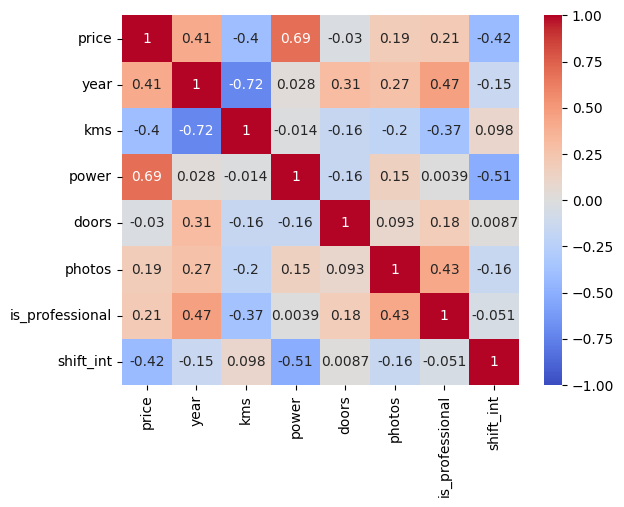

In [34]:
sns.heatmap(df.corr(numeric_only= True), annot= True, cmap="coolwarm", vmin=-1)

In [33]:
df.to_csv("../data/coches_proc.csv", index= False)